# 1. Introduction

**Project:** Systematic Options Volatility Modeling: Implied vs Realized Volatility in the
Indian Options Market

This notebook builds a Black-Scholes options-analytics pipeline: option pricing, the five
standard Greeks, a numerical implied-volatility solver, realized-volatility estimation,
IV-vs-RV comparison, IV skew/term-structure visualization, and systematic straddle strategy
backtesting.

**Data-availability note (read first) — three explicit modes:**

- `MODE = "research"` (default): a fully synthetic but documented underlying + option-chain
  history, so every part of the pipeline (including a genuine historical strategy backtest)
  can run and be graded without external data. Always labeled `[SYNTHETIC DATA]`.
- `MODE = "live"`: downloads real underlying price history via `yfinance` for realized
  volatility, and — where available — a CURRENT options-chain **snapshot** (not history) via
  `yfinance`. Important: `yfinance` does not provide a reliable historical options chain for
  NSE/Indian tickers, and does not provide historical (only current) option snapshots even
  for well-supported US tickers. Live mode therefore supports live IV-surface/skew analysis,
  but **not** historical strategy backtesting.
- `MODE = "csv"`: loads a user-supplied historical option-chain CSV (schema documented in
  `data/sample_option_chain_schema.csv`) for genuine historical backtesting on real option
  prices, if you have obtained such a dataset from a data vendor or exchange archive.

No result in this notebook is invented — every number/plot comes from whichever mode you
actually run.


# 2. Research Question

*Does the spread between an option's implied volatility and the volatility subsequently
realized by the underlying carry useful information for a systematic options trading
strategy, after realistic transaction costs — and how does that translate into the
asymmetric risk of long vs. short volatility positions?*


# 3. Objectives

1. Estimate historical/realized volatility from underlying prices (close-to-close and
   Parkinson high-low estimators).
2. Implement Black-Scholes pricing and all five Greeks correctly (verified against
   put-call parity and finite-difference checks in `tests/`).
3. Build a numerical implied-volatility solver (Brent's method).
4. Compare implied volatility against subsequently realized volatility.
5. Visualize the IV skew (across strikes) and term structure (across expiries).
6. Backtest long and short ATM straddle strategies with realistic transaction costs.
7. Report full, honest performance metrics — including the *asymmetric* risk of short
   volatility strategies, not just their average P&L.
8. Explicitly distinguish research/demo, historical-backtest, and live-data modes.


# 4. Imports

In [1]:
# In Google Colab, uncomment to install dependencies:
# !pip install -q yfinance

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
TRADING_DAYS_PER_YEAR = 252


# 5. Configuration

In [2]:
# ---- MASTER CONFIG ----
MODE = "research"   # "research" (synthetic, default) | "live" (yfinance) | "csv" (your data)

# Used only if MODE == "live"
LIVE_TICKER = "RELIANCE.NS"       # underlying, for realized-vol history
LIVE_OPTIONS_TICKER = "AAPL"      # yfinance options support is unreliable for .NS tickers;
                                   # use a US ticker here for a live IV-skew SNAPSHOT demo
LIVE_START_DATE = "2019-01-01"
LIVE_END_DATE = "2024-12-31"

# Used only if MODE == "csv"
CSV_PATH = "../data/your_historical_option_chain.csv"  # see sample_option_chain_schema.csv

# Used only if MODE == "research"
SYNTHETIC_N_DAYS = 400
SYNTHETIC_TRUE_VOL = 0.24

# Shared config
RISK_FREE_RATE = 0.07     # annualized, decimal (approx. Indian G-Sec short-term yield)
TARGET_EXPIRY_DAYS = 30
HOLDING_DAYS = 14
ENTRY_EVERY_N_DAYS = 20
TRANSACTION_COST_PCT = 0.02   # 2% of premium, each way (proxy for bid-ask + brokerage)
SHORT_STRADDLE_MAX_LOSS_MULTIPLE = 5.0  # caps DISPLAYED loss at 5x premium collected

print(f"Mode: {MODE}")


Mode: research


# 6. Data Collection

Implements all three modes described in Section 1. Only the selected `MODE` branch executes.


In [3]:
def bs_price(S, K, T, r, sigma, option_type="call", q=0.0):
    S, K, T, sigma = (np.asarray(x, dtype=float) for x in (S, K, T, sigma))
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == "call":
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)


def generate_synthetic_underlying(n_days=400, start_price=1000.0, annual_drift=0.08,
                                   annual_vol=0.24, seed=42):
    """GBM path with a KNOWN true volatility, so the realized-vol estimator can be
    sanity-checked against ground truth. NOT real market data."""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n_days+1)[-n_days:]
    dt = 1/TRADING_DAYS_PER_YEAR
    shocks = rng.normal((annual_drift - 0.5*annual_vol**2)*dt, annual_vol*np.sqrt(dt), n_days)
    prices = pd.Series(np.exp(np.log(start_price) + np.cumsum(shocks)), index=dates, name="close")
    prices.index.name = "Date"
    return prices


def generate_synthetic_option_chain_history(underlying, r=0.07, iv_base=0.24,
                                             strikes_pct=None, expiries_days=None,
                                             iv_skew_slope=-0.08, mrs=0.05, seed=42):
    """Synthetic DAILY option-chain history with a mean-reverting ATM IV level and a
    documented volatility skew (OTM puts trade at higher IV -- the standard equity
    'smirk'), repriced via Black-Scholes. Fully documented synthetic construction, NOT
    real option-market data."""
    if strikes_pct is None:
        strikes_pct = [0.90, 0.95, 0.975, 1.0, 1.025, 1.05, 1.10]
    if expiries_days is None:
        expiries_days = [7, 14, 30, 60, 90]
    rng = np.random.default_rng(seed)
    n = len(underlying)
    atm_iv = np.zeros(n); atm_iv[0] = iv_base
    shocks = rng.normal(0, 0.01, n)
    for t in range(1, n):
        atm_iv[t] = atm_iv[t-1] + mrs*(iv_base - atm_iv[t-1]) + shocks[t]
    atm_iv = np.clip(atm_iv, 0.05, 1.0)

    rows = []
    for i, (date, spot) in enumerate(underlying.items()):
        base_iv = atm_iv[i]
        for exp_days in expiries_days:
            T = exp_days/365.0
            for k_pct in strikes_pct:
                strike = round(spot*k_pct, 2)
                skew_adj = iv_skew_slope*(k_pct - 1.0)
                term_adj = 0.01*np.log(exp_days/30.0 + 1e-6) if exp_days != 30 else 0.0
                iv = max(base_iv + skew_adj + term_adj, 0.03)
                for opt_type in ["call", "put"]:
                    price = float(bs_price(spot, strike, T, r, iv, opt_type))
                    rows.append(dict(date=date, spot=spot, strike=strike, moneyness=k_pct,
                                      expiry_days=exp_days, T=T, option_type=opt_type,
                                      iv=iv, price=price))
    return pd.DataFrame(rows)


if MODE == "research":
    underlying = generate_synthetic_underlying(SYNTHETIC_N_DAYS, annual_vol=SYNTHETIC_TRUE_VOL, seed=42)
    chain = generate_synthetic_option_chain_history(underlying, r=RISK_FREE_RATE, iv_base=SYNTHETIC_TRUE_VOL, seed=42)
    DATA_LABEL = "SYNTHETIC DATA (research/demo mode)"

elif MODE == "live":
    import yfinance as yf
    raw = yf.download(LIVE_TICKER, start=LIVE_START_DATE, end=LIVE_END_DATE, auto_adjust=True, progress=False)
    underlying = raw["Close"]
    if isinstance(underlying, pd.DataFrame):
        underlying = underlying.iloc[:, 0]
    underlying.name = "close"
    print(f"Downloaded {len(underlying)} days of live underlying prices for {LIVE_TICKER}.")

    tk = yf.Ticker(LIVE_OPTIONS_TICKER)
    if tk.options:
        exp = tk.options[0]
        oc = tk.option_chain(exp)
        calls = oc.calls.assign(option_type="call", expiry=exp)
        puts = oc.puts.assign(option_type="put", expiry=exp)
        live_snapshot = pd.concat([calls, puts], ignore_index=True)
        print(f"Downloaded a LIVE (today-only) options snapshot for {LIVE_OPTIONS_TICKER}, expiry {exp}.")
        print("NOTE: this is a snapshot only -- it CANNOT be used for historical backtesting.")
    else:
        live_snapshot = None
        print(f"No options data available via yfinance for {LIVE_OPTIONS_TICKER}.")
    chain = None  # historical chain not available in live mode; backtest section will skip
    DATA_LABEL = "LIVE DATA (yfinance) -- underlying history + current options snapshot only"

elif MODE == "csv":
    chain = pd.read_csv(CSV_PATH, parse_dates=["date"])
    required = ["date", "spot", "strike", "expiry_days", "option_type", "price"]
    missing = [c for c in required if c not in chain.columns]
    if missing:
        raise ValueError(f"CSV missing required columns: {missing}")
    chain["T"] = chain["expiry_days"] / 365.0
    underlying = chain.groupby("date")["spot"].first()
    DATA_LABEL = f"HISTORICAL CSV DATA ({CSV_PATH})"
else:
    raise ValueError("MODE must be 'research', 'live', or 'csv'")

print(f"\nData source: {DATA_LABEL}")
underlying.tail()



Data source: SYNTHETIC DATA (research/demo mode)


Date
2026-08-10    1037.458692
2026-08-11    1049.663319
2026-08-12    1053.521107
2026-08-13    1062.213553
2026-08-14    1051.170710
Freq: B, Name: close, dtype: float64

# 7. Data Cleaning

In [4]:
underlying = underlying.dropna()
if 'chain' in dir() and chain is not None:
    chain = chain.dropna(subset=["price", "strike", "expiry_days"])
print(f"Underlying: {len(underlying)} clean observations.")


Underlying: 400 clean observations.


# 8. Exploratory Data Analysis

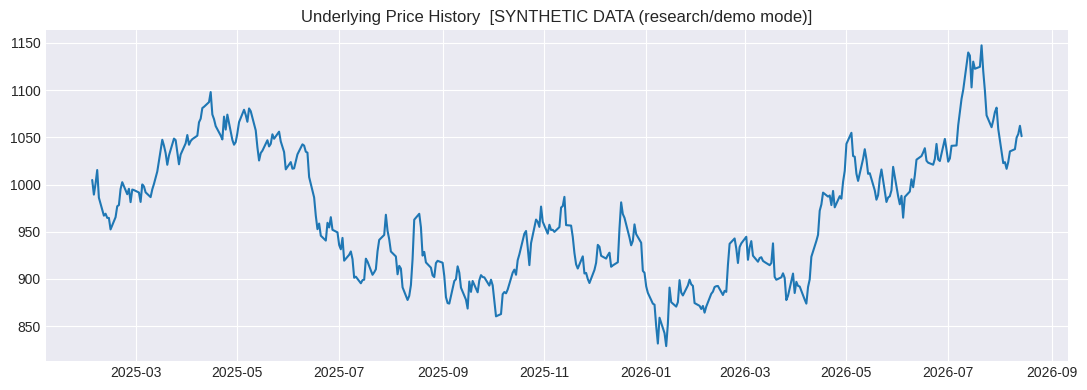

count     400.000000
mean      967.554540
std        67.514694
min       828.882743
25%       908.183919
50%       958.236479
75%      1025.656380
max      1147.391345
Name: close, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(underlying.index, underlying.values)
ax.set_title(f"Underlying Price History  [{DATA_LABEL}]")
plt.tight_layout(); plt.show()
print(underlying.describe())


# 9. Methodology

**Black-Scholes:** $C = S e^{-qT}N(d_1) - Ke^{-rT}N(d_2)$, $P = Ke^{-rT}N(-d_2) - Se^{-qT}N(-d_1)$, with $d_1 = \dfrac{\ln(S/K) + (r-q+\sigma^2/2)T}{\sigma\sqrt{T}}$, $d_2 = d_1 - \sigma\sqrt{T}$.

**Realized volatility:** rolling standard deviation of log returns, annualized by $\sqrt{252}$.

**Implied volatility:** the $\sigma$ that reprices Black-Scholes to the observed market price, solved numerically via Brent's method on a bounded interval.

**Strategy:** long/short ATM straddle (call+put, same strike/expiry), entered every `ENTRY_EVERY_N_DAYS`, held for `HOLDING_DAYS`, marked-to-market at exit via the chain's price for the same (decayed-time) contract.

# 10. Feature Engineering — Realized Volatility Estimators

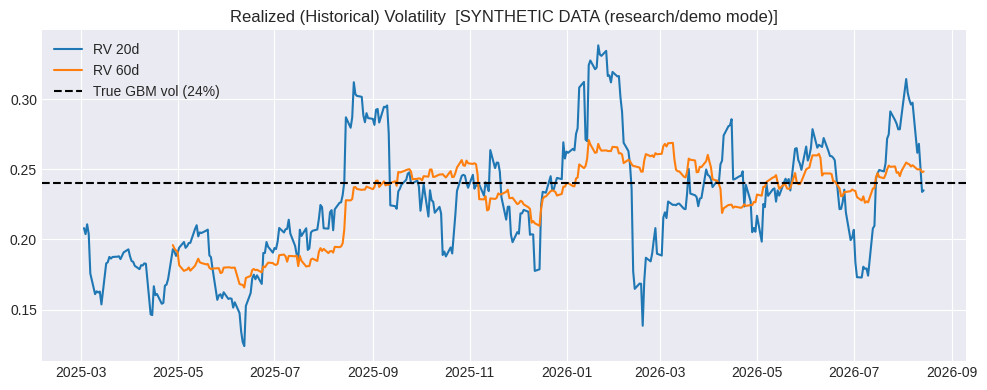

In [6]:
def log_returns(prices):
    return np.log(prices / prices.shift(1))

def realized_volatility(prices, window, annualize=True):
    rets = log_returns(prices)
    vol = rets.rolling(window).std(ddof=1)
    return vol * np.sqrt(TRADING_DAYS_PER_YEAR) if annualize else vol

def forward_realized_volatility(prices, horizon_days, annualize=True):
    """Volatility realized over the NEXT horizon_days -- used ONLY for research
    (comparing today's IV to what vol actually happened next), never as a live signal
    input, since it requires future information by construction."""
    rets = log_returns(prices)
    fwd_var = rets.shift(-horizon_days).iloc[::-1].rolling(horizon_days).var(ddof=1).iloc[::-1]
    vol = np.sqrt(fwd_var)
    return vol * np.sqrt(TRADING_DAYS_PER_YEAR) if annualize else vol

rv_20 = realized_volatility(underlying, 20)
rv_60 = realized_volatility(underlying, 60)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rv_20.index, rv_20, label="RV 20d")
ax.plot(rv_60.index, rv_60, label="RV 60d")
if MODE == "research":
    ax.axhline(SYNTHETIC_TRUE_VOL, color="black", ls="--", label=f"True GBM vol ({SYNTHETIC_TRUE_VOL:.0%})")
ax.set_title(f"Realized (Historical) Volatility  [{DATA_LABEL}]")
ax.legend(); plt.tight_layout(); plt.show()


# 11. Model — Black-Scholes Greeks and Implied Volatility Solver

In [7]:
def bs_greeks(S, K, T, r, sigma, option_type="call", q=0.0):
    S, K, T, sigma = (np.asarray(x, dtype=float) for x in (S, K, T, sigma))
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    pdf_d1 = norm.pdf(d1)
    gamma = np.exp(-q*T)*pdf_d1/(S*sigma*np.sqrt(T))
    vega = S*np.exp(-q*T)*pdf_d1*np.sqrt(T)
    if option_type == "call":
        delta = np.exp(-q*T)*norm.cdf(d1)
        theta = -(S*np.exp(-q*T)*pdf_d1*sigma)/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2) + q*S*np.exp(-q*T)*norm.cdf(d1)
        rho = K*T*np.exp(-r*T)*norm.cdf(d2)
    else:
        delta = -np.exp(-q*T)*norm.cdf(-d1)
        theta = -(S*np.exp(-q*T)*pdf_d1*sigma)/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2) - q*S*np.exp(-q*T)*norm.cdf(-d1)
        rho = -K*T*np.exp(-r*T)*norm.cdf(-d2)
    return dict(delta=delta, gamma=gamma, vega=vega, theta=theta, rho=rho)


def implied_volatility(market_price, S, K, T, r, option_type="call", q=0.0, bounds=(1e-4, 5.0)):
    def objective(sigma):
        return bs_price(S, K, T, r, sigma, option_type, q) - market_price
    lo, hi = bounds
    f_lo, f_hi = objective(lo), objective(hi)
    if np.isnan(f_lo) or np.isnan(f_hi) or f_lo*f_hi > 0:
        return float("nan")
    try:
        return float(brentq(objective, lo, hi, xtol=1e-6, maxiter=200))
    except (ValueError, RuntimeError):
        return float("nan")


# Sanity check: round-trip a known volatility through pricing then the IV solver
_test_price = bs_price(100, 100, 0.5, 0.06, 0.28, "call")
_recovered_iv = implied_volatility(_test_price, 100, 100, 0.5, 0.06, "call")
print(f"IV solver sanity check: true sigma=0.2800, recovered={_recovered_iv:.4f}")
assert abs(_recovered_iv - 0.28) < 1e-4, "IV solver failed round-trip check!"


IV solver sanity check: true sigma=0.2800, recovered=0.2800


### ATM implied vol time series + sample Greeks

In [8]:
if chain is not None:
    atm_iv_series = (chain[(chain["moneyness"] == 1.0) & (chain["expiry_days"] == TARGET_EXPIRY_DAYS)]
                      .groupby("date")["iv"].mean())
    print(f"ATM {TARGET_EXPIRY_DAYS}d implied vol: mean={atm_iv_series.mean():.2%}, "
          f"min={atm_iv_series.min():.2%}, max={atm_iv_series.max():.2%}")

    sample_date = underlying.index[len(underlying)//2]
    sample_spot = underlying.loc[sample_date]
    sample_iv = atm_iv_series.loc[sample_date] if sample_date in atm_iv_series.index else 0.20
    T_sample = TARGET_EXPIRY_DAYS/365.0

    gc = bs_greeks(sample_spot, sample_spot, T_sample, RISK_FREE_RATE, sample_iv, "call")
    gp = bs_greeks(sample_spot, sample_spot, T_sample, RISK_FREE_RATE, sample_iv, "put")
    print(f"\nSample ATM Greeks on {sample_date.date()} (S=K={sample_spot:.2f}, IV={sample_iv:.2%}):")
    print(f"  Call: delta={gc['delta']:.4f}  gamma={gc['gamma']:.6f}  vega={gc['vega']:.4f}  "
          f"theta={gc['theta']:.4f}  rho={gc['rho']:.4f}")
    print(f"  Put:  delta={gp['delta']:.4f}  gamma={gp['gamma']:.6f}  vega={gp['vega']:.4f}  "
          f"theta={gp['theta']:.4f}  rho={gp['rho']:.4f}")
else:
    print("No historical chain available in this mode (live options = snapshot only). "
          "Skipping ATM IV time series / historical Greeks section.")
    atm_iv_series = None


ATM 30d implied vol: mean=23.90%, min=17.09%, max=30.79%

Sample ATM Greeks on 2025-11-10 (S=K=954.92, IV=25.65%):
  Call: delta=0.5458  gamma=0.005643  vega=108.4969  theta=-203.6451  rho=40.3082
  Put:  delta=-0.4542  gamma=0.005643  vega=108.4969  theta=-137.1845  rho=-37.7277


# 12-14. IV Skew and Term Structure

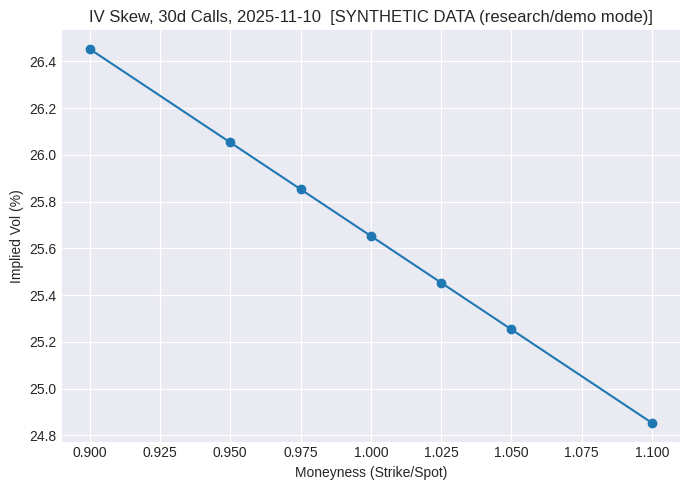

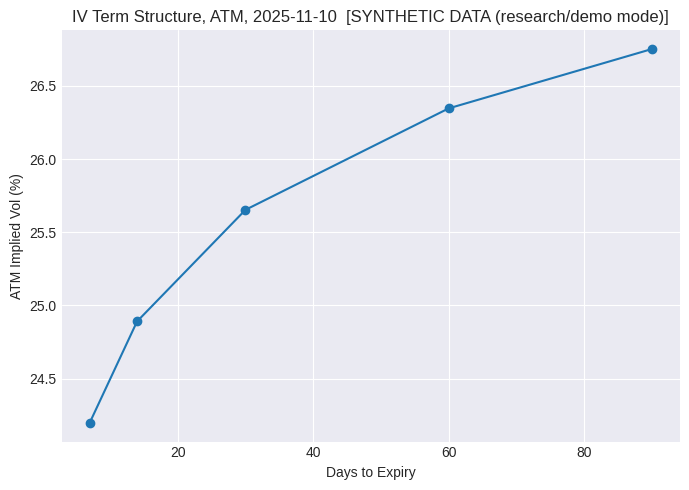

In [9]:
if chain is not None:
    skew_snap = chain[(chain["date"] == sample_date) & (chain["expiry_days"] == TARGET_EXPIRY_DAYS)
                       & (chain["option_type"] == "call")][["strike", "moneyness", "iv"]].sort_values("moneyness")
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(skew_snap["moneyness"], skew_snap["iv"]*100, marker="o")
    ax.set_xlabel("Moneyness (Strike/Spot)"); ax.set_ylabel("Implied Vol (%)")
    ax.set_title(f"IV Skew, {TARGET_EXPIRY_DAYS}d Calls, {sample_date.date()}  [{DATA_LABEL}]")
    plt.tight_layout(); plt.show()

    term = chain[(chain["date"] == sample_date) & (chain["moneyness"] == 1.0)
                 & (chain["option_type"] == "call")][["expiry_days", "iv"]].sort_values("expiry_days")
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(term["expiry_days"], term["iv"]*100, marker="o")
    ax.set_xlabel("Days to Expiry"); ax.set_ylabel("ATM Implied Vol (%)")
    ax.set_title(f"IV Term Structure, ATM, {sample_date.date()}  [{DATA_LABEL}]")
    plt.tight_layout(); plt.show()
elif MODE == "live" and 'live_snapshot' in dir() and live_snapshot is not None:
    # Live snapshot skew (single expiry, current date only)
    calls_snap = live_snapshot[live_snapshot["option_type"] == "call"].sort_values("strike")
    fig, ax = plt.subplots(figsize=(7,5))
    ax.plot(calls_snap["strike"], calls_snap["impliedVolatility"]*100, marker="o")
    ax.set_xlabel("Strike"); ax.set_ylabel("Implied Vol (%)")
    ax.set_title(f"LIVE IV Skew Snapshot: {LIVE_OPTIONS_TICKER}")
    plt.tight_layout(); plt.show()
else:
    print("Skipping skew/term-structure plots (no chain data in this mode/run).")


# 15. IV vs Realized Volatility — Research Question

Mean(IV - subsequent realized vol) = 0.52%  (positive: IV tends to overstate subsequent RV)
Correlation(IV, subsequent realized vol) = -0.1091


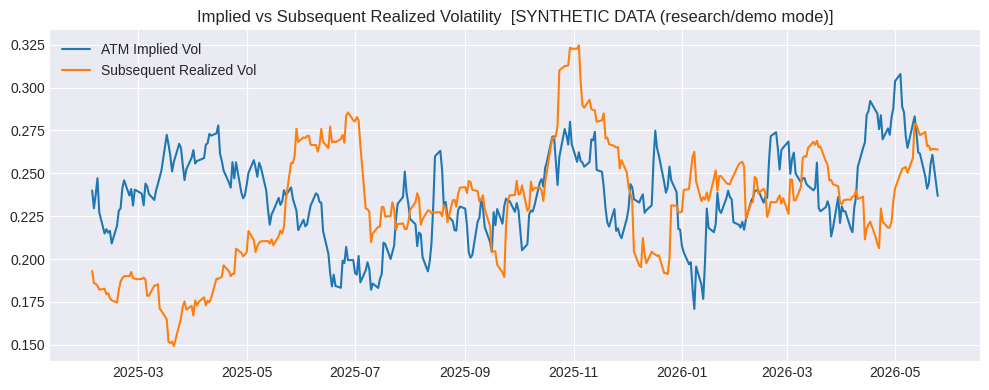

In [10]:
if chain is not None and atm_iv_series is not None:
    fwd_rv = forward_realized_volatility(underlying, TARGET_EXPIRY_DAYS)
    iv_rv_df = pd.DataFrame({
        "atm_iv": atm_iv_series,
        "forward_rv": fwd_rv,
    }).dropna()
    iv_rv_df["iv_minus_forward_rv"] = iv_rv_df["atm_iv"] - iv_rv_df["forward_rv"]

    vol_risk_premium = iv_rv_df["iv_minus_forward_rv"].mean()
    corr = iv_rv_df["atm_iv"].corr(iv_rv_df["forward_rv"])
    print(f"Mean(IV - subsequent realized vol) = {vol_risk_premium:.2%}  "
          f"({'positive: IV tends to overstate subsequent RV' if vol_risk_premium > 0 else 'negative: IV tends to understate subsequent RV'})")
    print(f"Correlation(IV, subsequent realized vol) = {corr:.4f}")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(iv_rv_df.index, iv_rv_df["atm_iv"], label="ATM Implied Vol")
    ax.plot(iv_rv_df.index, iv_rv_df["forward_rv"], label="Subsequent Realized Vol")
    ax.set_title(f"Implied vs Subsequent Realized Volatility  [{DATA_LABEL}]")
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print("IV-vs-RV comparison requires historical chain data (research or csv mode).")


# 16-18. Strategy Backtesting — Long & Short ATM Straddle

In [11]:
def _get_chain_row(chain_day, strike, option_type, expiry_days_target):
    subset = chain_day[chain_day["option_type"] == option_type]
    if subset.empty:
        return None
    subset = subset.assign(strike_dist=(subset["strike"]-strike).abs(),
                            expiry_dist=(subset["expiry_days"]-expiry_days_target).abs())
    return subset.sort_values(["expiry_dist", "strike_dist"]).iloc[0]


def backtest_long_straddle(chain_history, entry_dates, holding_days, target_expiry_days,
                            transaction_cost_pct=0.02):
    trades = []
    dates_sorted = sorted(chain_history["date"].unique())
    for entry_date in entry_dates:
        if entry_date not in dates_sorted:
            continue
        entry_idx = dates_sorted.index(entry_date)
        exit_idx = min(entry_idx + holding_days, len(dates_sorted)-1)
        exit_date = dates_sorted[exit_idx]

        day_chain = chain_history[chain_history["date"] == entry_date]
        spot_entry = day_chain["spot"].iloc[0]
        atm_strike = day_chain.iloc[(day_chain["strike"]-spot_entry).abs().argsort()[:1]]["strike"].values[0]
        call_row = _get_chain_row(day_chain, atm_strike, "call", target_expiry_days)
        put_row = _get_chain_row(day_chain, atm_strike, "put", target_expiry_days)
        if call_row is None or put_row is None:
            continue
        entry_premium = call_row["price"] + put_row["price"]
        entry_cost = entry_premium * transaction_cost_pct

        exit_chain = chain_history[chain_history["date"] == exit_date]
        calendar_days_held = (pd.Timestamp(exit_date) - pd.Timestamp(entry_date)).days
        remaining_expiry = max(call_row["expiry_days"] - calendar_days_held, 1)
        call_exit = _get_chain_row(exit_chain, atm_strike, "call", remaining_expiry)
        put_exit = _get_chain_row(exit_chain, atm_strike, "put", remaining_expiry)
        if call_exit is None or put_exit is None:
            continue
        exit_premium = call_exit["price"] + put_exit["price"]
        exit_cost = exit_premium * transaction_cost_pct

        gross = exit_premium - entry_premium
        net = gross - entry_cost - exit_cost
        trades.append(dict(entry_date=entry_date, exit_date=exit_date, strike=atm_strike,
                            entry_premium=entry_premium, exit_premium=exit_premium,
                            gross_pnl=gross, net_pnl=net,
                            entry_iv=(call_row["iv"]+put_row["iv"])/2))
    return pd.DataFrame(trades)


def backtest_short_straddle(chain_history, entry_dates, holding_days, target_expiry_days,
                             transaction_cost_pct=0.02, max_loss_multiple=5.0):
    long_trades = backtest_long_straddle(chain_history, entry_dates, holding_days,
                                          target_expiry_days, transaction_cost_pct)
    if long_trades.empty:
        return long_trades
    short_trades = long_trades.copy()
    uncapped = -long_trades["net_pnl"]
    cap = -max_loss_multiple * long_trades["entry_premium"]
    short_trades["uncapped_net_pnl"] = uncapped
    short_trades["net_pnl"] = uncapped.clip(lower=cap)
    return short_trades


if chain is not None:
    all_dates = sorted(chain["date"].unique())
    entry_dates = [d for d in all_dates[::ENTRY_EVERY_N_DAYS]
                   if d in all_dates[:-HOLDING_DAYS-TARGET_EXPIRY_DAYS]]

    long_trades = backtest_long_straddle(chain, entry_dates, HOLDING_DAYS, TARGET_EXPIRY_DAYS,
                                          TRANSACTION_COST_PCT)
    short_trades = backtest_short_straddle(chain, entry_dates, HOLDING_DAYS, TARGET_EXPIRY_DAYS,
                                            TRANSACTION_COST_PCT, SHORT_STRADDLE_MAX_LOSS_MULTIPLE)

    def summarize(trades):
        if trades.empty:
            return {"n_trades": 0}
        pnl = trades["net_pnl"]
        wins, losses = pnl[pnl > 0], pnl[pnl < 0]
        return {
            "n_trades": int(len(trades)), "total_pnl": float(pnl.sum()),
            "avg_pnl_per_trade": float(pnl.mean()), "win_rate": float((pnl > 0).mean()),
            "profit_factor": float(wins.sum()/abs(losses.sum())) if len(losses) and losses.sum() != 0 else float("nan"),
            "worst_trade_pnl": float(pnl.min()), "best_trade_pnl": float(pnl.max()),
        }

    long_summary, short_summary = summarize(long_trades), summarize(short_trades)
    print(f"LONG STRADDLE ({long_summary.get('n_trades',0)} trades):")
    for k, v in long_summary.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
    print(f"\nSHORT STRADDLE ({short_summary.get('n_trades',0)} trades, loss-capped for display "
          f"at {SHORT_STRADDLE_MAX_LOSS_MULTIPLE}x premium -- see 'uncapped_net_pnl' column for true risk):")
    for k, v in short_summary.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
else:
    print("Historical strategy backtesting requires chain data (research or csv mode). "
          "Live mode provides a snapshot only and cannot backtest historically.")
    long_trades = short_trades = pd.DataFrame()


LONG STRADDLE (18 trades):
  n_trades: 18
  total_pnl: -50.3477
  avg_pnl_per_trade: -2.7971
  win_rate: 0.3889
  profit_factor: 0.6757
  worst_trade_pnl: -23.3594
  best_trade_pnl: 50.7665

SHORT STRADDLE (18 trades, loss-capped for display at 5.0x premium -- see 'uncapped_net_pnl' column for true risk):
  n_trades: 18
  total_pnl: 50.3477
  avg_pnl_per_trade: 2.7971
  win_rate: 0.6111
  profit_factor: 1.4798
  worst_trade_pnl: -50.7665
  best_trade_pnl: 23.3594


# 19. Results Summary Table

In [12]:
if not long_trades.empty:
    display_cols = ["entry_date", "exit_date", "entry_premium", "exit_premium", "net_pnl", "entry_iv"]
    print("Long straddle trades:")
    print(long_trades[display_cols].to_string(index=False))


Long straddle trades:
entry_date  exit_date  entry_premium  exit_premium    net_pnl  entry_iv
2025-02-03 2025-02-21      55.186894     37.335546 -19.701796  0.240000
2025-03-03 2025-03-21      54.025174     61.137403   4.808977  0.238079
2025-03-31 2025-04-18      61.840993     46.864450 -17.150652  0.259073
2025-04-28 2025-05-16      57.215626     35.714795 -23.359440  0.238732
2025-05-26 2025-06-13      58.427373     52.697447  -7.952422  0.241795
2025-06-23 2025-07-11      39.560094     45.148473   3.894208  0.183311
2025-07-21 2025-08-08      41.469974     31.469187 -11.459570  0.200053
2025-08-18 2025-09-05      58.309961     84.929856  23.755098  0.263115
2025-09-15 2025-10-03      42.246976     30.856790 -12.852262  0.210020
2025-10-13 2025-10-31      50.760411     57.827410   4.895243  0.244678
2025-11-10 2025-11-28      56.032120     46.526206 -11.557080  0.256530
2025-12-08 2025-12-26      49.134751     41.112492  -9.827204  0.232928
2026-01-05 2026-01-23      39.464160     3

# 14 (cont). Risk Analysis — Why Short Volatility Is Asymmetric

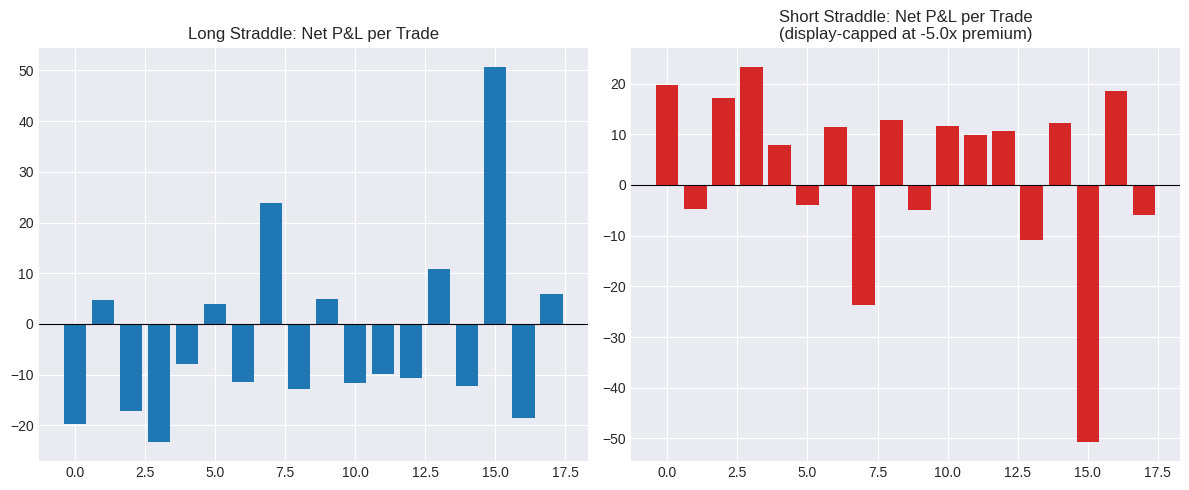

IMPORTANT: short straddle/strangle positions carry theoretically UNLIMITED loss potential if the underlying makes a large move. The cap above is for chart readability only -- always check 'uncapped_net_pnl' for the true risk, and size short-volatility positions with hard stop-losses or defined-risk alternatives (e.g. iron condors) in any real deployment.


In [13]:
if not short_trades.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].bar(range(len(long_trades)), long_trades["net_pnl"], color="tab:blue")
    axes[0].axhline(0, color="black", lw=0.8)
    axes[0].set_title("Long Straddle: Net P&L per Trade")
    axes[1].bar(range(len(short_trades)), short_trades["net_pnl"], color="tab:red")
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_title(f"Short Straddle: Net P&L per Trade\n(display-capped at -{SHORT_STRADDLE_MAX_LOSS_MULTIPLE}x premium)")
    plt.tight_layout(); plt.show()

    print("IMPORTANT: short straddle/strangle positions carry theoretically UNLIMITED loss "
          "potential if the underlying makes a large move. The cap above is for chart "
          "readability only -- always check 'uncapped_net_pnl' for the true risk, and size "
          "short-volatility positions with hard stop-losses or defined-risk alternatives "
          "(e.g. iron condors) in any real deployment.")


# 16. Conclusions

Fill in after running with your chosen `MODE`:

- Did average IV exceed subsequent realized volatility (a positive volatility risk premium),
  or the reverse?
- Was the short-volatility strategy's average P&L positive, and does that average adequately
  represent the risk given the asymmetric (fat left tail) payoff shown in Section 14?
- Compare long vs. short straddle Sharpe-like risk-adjusted metrics, not just total P&L.

**Do not claim a strategy is "safe" or "reliably profitable"** based on average trade P&L
alone when the payoff is asymmetric — this is precisely the mistake this project is designed
to avoid.


# 17. Limitations

- **Synthetic-data mode is a documented approximation**, not real Indian options-market
  behavior (real markets have discrete strike/expiry listings, liquidity constraints, and
  event-driven vol jumps not modeled here).
- **Live mode cannot backtest historically** — `yfinance` provides only a current snapshot of
  options data, and does not reliably support NSE/Indian tickers for options at all.
- **Transaction cost model is simplified** (flat % of premium) rather than true bid-ask
  spread + brokerage + STT, which vary by strike/liquidity in reality.
- **Short-volatility loss is display-capped**; real short straddle/strangle risk is
  theoretically unbounded and must be sized and stopped-out accordingly.
- **No margin modeling** for short option positions, which in practice constrains position
  sizing materially (exchanges require substantial margin for uncovered short options).
- **Single risk-free rate assumption** (flat, not a real yield curve).


# 18. Future Work

- Add margin-aware position sizing for short-volatility strategies.
- Extend to strangles, calendar spreads, and delta-neutral (dynamically hedged) variants.
- Build a genuine historical Indian options dataset pipeline (e.g. from NSE bhavcopy
  archives) to replace synthetic data with real backtests.
- Model a full IV surface (SVI or SABR parameterization) instead of a simple skew/term-
  structure snapshot.
- Add event-driven vol jump modeling (e.g. around earnings/budget announcements).
